# Data based measurement of the nearest neighbor intrinsic dimensions (NNID)

This notebook implements the data measurement of the nearest neighbor intrinsic dimensionality of a sample of jets.
This involves the following:

1. Cluster jets and isolate a randomly skimmed selection of jets within a pT bin (default 330 to 370 GeV) using every event sample needed to build the measurement.
2. Calculate the EMD between every jet in this selection. For computational reasons, we limit to 50k jets per event sample in the analysis.
3. Sort the columns of the EMD matrix into increasing order so nearest neighbors can be quickly computed
4. Use a negative log-likelihood minimization to extract the maximum likelihood estimate for the intrinsic dimension. This is done repeatedly for different values of the unphysical index "i" as specified in https://arxiv.org/pdf/2511.20760. Additionally extract the **median** EMD at a given index, allowing the intrinsic dimension to be plotted against a physical scale.

Note that the nearest neighbors are computed as weighted generalizations.
See `nnid_utils.py` for details.
Given the analysis is somewhat complicated and compute intensive, this notebook will take a long time to run even with resources that can run the calculations in parallel.

## Preliminaries: load all data

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"
import numpy as np
import pandas as pd
import fastjet as fj

import id_utils as utils
import visualize as vis

In [3]:
# ROOT file paths
staging_dir = "/pscratch/sd/k/kgreif/zjets_plot_staging/final_public_data"
tree_name = "OmniTree"

truth_mc_path = f"{staging_dir}/truth_mc_events.root"
truth_hv_path = f"{staging_dir}/truth_mc_hv_events.root"
truth_madgraph_path = f"{staging_dir}/truth_madgraph/truth_madgraph_events.root"
truth_sherpa_path = f"{staging_dir}/truth_sherpa/truth_sherpa_events.root"

In [4]:
# Load event weights for data measurement
data_weights = pd.read_hdf("/pscratch/sd/k/kgreif/zjets_plot_staging/final_public_data/data_weights.h5")
data_hv_weights = pd.read_hdf("/pscratch/sd/k/kgreif/zjets_plot_staging/final_public_data/data_hv_weights.h5")
truth_madgraph_weights = pd.read_hdf("/pscratch/sd/k/kgreif/zjets_plot_staging/final_public_data/truth_madgraph/truth_madgraph_weights.h5")
truth_sherpa_weights = pd.read_hdf("/pscratch/sd/k/kgreif/zjets_plot_staging/final_public_data/truth_sherpa/truth_sherpa_weights.h5")

## Calculate EMDs

WARNING: The below will require about 80 GB of disk space for the storage of EMD matrices.
Reduce the `max_jets` parameter to reduce disk footprint.

In [6]:
# Set parameters for jet clustering
algorithm = fj.antikt_algorithm
R = 1.0
ptmin = 330.0
ptmax = 370.0
etamax = 1.2
max_jets = 50000

# Set location for EMD storage, set to None to not save
emd_dir = "./emd_storage"
if not os.path.exists(emd_dir) and emd_dir is not None:
    os.makedirs(emd_dir)

In [ ]:
# Calculate EMDs for madgraph
utils.calculate_emds_from_file(
    truth_mc_path,
    tree_name,
    algorithm,
    R,
    ptmin=ptmin,
    ptmax=ptmax,
    etamax=etamax,
    n_jobs=-1,
    max_jets=max_jets,
    save_path="./emd_storage/truth_mc_emds_330to370.npz",
    save_jet_info=True,
)

In [ ]:
# Calculate EMDs for hidden variable events
utils.calculate_emds_from_file(
    truth_hv_path,
    tree_name,
    algorithm,
    R,
    ptmin=ptmin,
    ptmax=ptmax,
    etamax=etamax,
    n_jobs=-1,
    max_jets=max_jets,
    save_path="./emd_storage/truth_mc_hv_emds_330to370.npz",
)

In [7]:
# Calculate EMDs for truth madgraph
utils.calculate_emds_from_file(
    truth_madgraph_path,
    tree_name,
    algorithm,
    R,
    ptmin=ptmin,
    ptmax=ptmax,
    etamax=etamax,
    n_jobs=-1,
    max_jets=max_jets,
    save_path="./emd_storage/truth_madgraph_emds_330to370.npz",
)

Preparing 3622662 events for clustering
Processing 3622662 events with 256 jobs


Clustering events:   0%|          | 0/3622662 [00:00<?, ?event/s]

#--------------------------------------------------------------------------
#                         FastJet release 3.5.1
#                 M. Cacciari, G.P. Salam and G. Soyez                  
#     A software package for jet finding and analysis at colliders      
#                           https://fastjet.fr                           
#	                                                                      
# Please cite EPJC72(2012)1896 [arXiv:1111.6097] if you use this package
# for scientific work and optionally PLB641(2006)57 [hep-ph/0512210].   
#                                                                       
# FastJet is provided without warranty under the GNU GPL v2 or higher.  
# It uses T. Chan's closest pair algorithm, S. Fortune's Voronoi code,
# CGAL and 3rd party plugin jet algorithms. See COPYING file for details.
#--------------------------------------------------------------------------
#---------------------------------------------------------------------

Clustering events:   0%|          | 1/3622662 [00:01<1092:36:14,  1.09s/event]

#--------------------------------------------------------------------------
#--------------------------------------------------------------------------
#                         FastJet release #                         FastJet release 3.5.13.5.1

#                 M. Cacciari, G.P. Salam and G. Soyez                  
#                 M. Cacciari, G.P. Salam and G. Soyez                  
#     A software package for jet finding and analysis at colliders      
#     A software package for jet finding and analysis at colliders      
#                           https://fastjet.fr                           
#                           https://fastjet.fr                           
#	                                                                      
#	                                                                      
# Please cite EPJC72(2012)1896 [arXiv:1111.6097] if you use this package
# Please cite EPJC72(2012)1896 [arXiv:1111.6097] if you use this package
# for scientific wor

...

Clustering events:   0%|          | 11/3622662 [00:02<195:01:30,  5.16event/s]

#--------------------------------------------------------------------------
#                         FastJet release 3.5.1
#                 M. Cacciari, G.P. Salam and G. Soyez                  
#     A software package for jet finding and analysis at colliders      
#                           https://fastjet.fr                           
#	                                                                      
# Please cite EPJC72(2012)1896 [arXiv:1111.6097] if you use this package
# for scientific work and optionally PLB641(2006)57 [hep-ph/0512210].   
#                                                                       
# FastJet is provided without warranty under the GNU GPL v2 or higher.  
# It uses T. Chan's closest pair algorithm, S. Fortune's Voronoi code,
# CGAL and 3rd party plugin jet algorithms. See COPYING file for details.
#--------------------------------------------------------------------------
#---------------------------------------------------------------------

Clustering events: 100%|██████████| 3622662/3622662 [01:56<00:00, 31153.77event/s]


Clustered 1364236 jets from 3622662 events
Filtered to 286878 jets (ptmin=330.0, ptmax=370.0, etamax=1.2)
Randomly sampled 50000 jets (dropped 236878 jets)
Calculating EMDs...
Got mean pT of 348.74730227791315 GeV
Got min pT of 330.0001614240318 GeV
Got max pT of 369.99894962162887 GeV
PairwiseEMD
  ArrayEvent<8-byte float, variable particle dimension>
    norm - true
    external_dists - false

  EuclideanArrayDistance
    R - 1
    beta - 1

  NetworkSimplex
    n_iter_max - 100000
    epsilon_large - 2.22045e-12
    epsilon_small - 2.22045e-16

  num_threads - 256
  print_every - 50000000
  request_mode - false
  store_sym_emds_raw - true
  throw_on_error - true
  omp_dynamic_chunksize - 10

  Pairwise EMD distance matrix stored internally

Finished preprocessing 50000 events in 0.9634s
    50000000 / 1249975000  EMDs computed  -   4.00% completed - 5.420s
   100000000 / 1249975000  EMDs computed  -   8.00% completed - 9.908s
   150000000 / 1249975000  EMDs computed  -  12.00% compl

(array([[ 0.        , 20.26722621, 19.80359438, ..., 45.07713622,
         81.76700382,  4.90613255],
        [ 0.        ,  0.        , 17.88013331, ..., 47.37113   ,
         73.94004648, 21.22809203],
        [ 0.        ,  0.        ,  0.        , ..., 46.15598499,
         79.85954195, 17.88392428],
        ...,
        [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         83.30528655, 43.45666411],
        [ 0.        ,  0.        ,  0.        , ...,  0.        ,
          0.        , 82.31651815],
        [ 0.        ,  0.        ,  0.        , ...,  0.        ,
          0.        ,  0.        ]]),
 array([     26,      53,     203, ..., 3622386, 3622594, 3622649]))

In [8]:
# Calculate EMDs for sherpa
utils.calculate_emds_from_file(
    truth_sherpa_path,
    tree_name,
    algorithm,
    R,
    ptmin=ptmin,
    ptmax=ptmax,
    etamax=etamax,
    n_jobs=-1,
    max_jets=max_jets,
    save_path="./emd_storage/truth_sherpa_emds_330to370.npz",
)

Preparing 5123149 events for clustering
Processing 5123149 events with 256 jobs


Clustering events:   0%|          | 3113/5123149 [00:00<05:20, 15954.23event/s]

#--------------------------------------------------------------------------
#                         FastJet release 3.5.1
#                 M. Cacciari, G.P. Salam and G. Soyez                  
#     A software package for jet finding and analysis at colliders      
#                           https://fastjet.fr                           
#	                                                                      
# Please cite EPJC72(2012)1896 [arXiv:1111.6097] if you use this package
# for scientific work and optionally PLB641(2006)57 [hep-ph/0512210].   
#                                                                       
# FastJet is provided without warranty under the GNU GPL v2 or higher.  
# It uses T. Chan's closest pair algorithm, S. Fortune's Voronoi code,
# CGAL and 3rd party plugin jet algorithms. See COPYING file for details.
#--------------------------------------------------------------------------
#---------------------------------------------------------------------

Clustering events: 100%|██████████| 5123149/5123149 [02:49<00:00, 30235.77event/s]


Clustered 1980759 jets from 5123149 events
Filtered to 408031 jets (ptmin=330.0, ptmax=370.0, etamax=1.2)
Randomly sampled 50000 jets (dropped 358031 jets)
Calculating EMDs...
Got mean pT of 348.83489097935274 GeV
Got min pT of 330.00015531752103 GeV
Got max pT of 369.9999275542299 GeV
PairwiseEMD
  ArrayEvent<8-byte float, variable particle dimension>
    norm - true
    external_dists - false

  EuclideanArrayDistance
    R - 1
    beta - 1

  NetworkSimplex
    n_iter_max - 100000
    epsilon_large - 2.22045e-12
    epsilon_small - 2.22045e-16

  num_threads - 256
  print_every - 50000000
  request_mode - false
  store_sym_emds_raw - true
  throw_on_error - true
  omp_dynamic_chunksize - 10

  Pairwise EMD distance matrix stored internally

Finished preprocessing 50000 events in 0.9721s
    50000000 / 1249975000  EMDs computed  -   4.00% completed - 7.063s
   100000000 / 1249975000  EMDs computed  -   8.00% completed - 13.041s
   150000000 / 1249975000  EMDs computed  -  12.00% comp

(array([[ 0.        , 33.29931784, 68.45610832, ..., 36.68848692,
         36.9648377 , 73.46690208],
        [ 0.        ,  0.        , 58.02762201, ...,  9.32109881,
         12.90307127, 63.21741635],
        [ 0.        ,  0.        ,  0.        , ..., 59.78618135,
         56.54542781, 26.0100597 ],
        ...,
        [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         10.43119495, 65.82300803],
        [ 0.        ,  0.        ,  0.        , ...,  0.        ,
          0.        , 63.4739937 ],
        [ 0.        ,  0.        ,  0.        , ...,  0.        ,
          0.        ,  0.        ]]),
 array([      2,      12,     153, ..., 5122660, 5122883, 5123028]))

## Measurement with data

All EMDs should have been calculated and written to disk.
Build dictionary of event weights for each sample.

In [5]:
# Create dictionary describing all of the histograms needed for the data measurement
nominal_weights = data_weights["weights_nominal"]
n_init_weights = [name for name in data_weights.keys() if "weights_ensemble_" in name]
dbootstrap_weights = [name for name in data_weights.keys() if "weights_bootstrap_data_" in name]
mcbootstrap_train_weights = [
    name for name in data_weights.keys() if "weights_bootstrap_mc_" in name
]
data_weights_dict = {
    "nominal": data_weights["weights_nominal"].to_numpy(),
    **{
        f"ensemble_{i}": data_weights[name].to_numpy()
        for i, name in enumerate(n_init_weights)
    },
    **{
        f"bootstrap_data_{i}": data_weights[name].to_numpy()
        for i, name in enumerate(dbootstrap_weights)
    },
    **{
        f"bootstrap_mc_{i}": data_weights[name].to_numpy()
        for i, name in enumerate(mcbootstrap_train_weights)
    },
    **{
        f"bootstrap_mc_test_{i}": utils.poisson_bootstrap_weights(nominal_weights)
        for i in range(25)
    },
    "trackEffMain": data_weights["weights_trackEffMain"].to_numpy(),
    "trackEffJet": data_weights["weights_trackEffJet"].to_numpy(),
    "trackFake": data_weights["weights_trackFake"].to_numpy(),
    "trackPtScale": data_weights["weights_trackPtScale"].to_numpy(),
    "muCalID": data_weights["weights_muCalID"].to_numpy(),
    "muCalMS": data_weights["weights_muCalMS"].to_numpy(),
    "muCalResBias": data_weights["weights_muCalResBias"].to_numpy(),
    "muCalScale": data_weights["weights_muCalScale"].to_numpy(),
    "muEffReco": data_weights["weights_muEffReco"].to_numpy(),
    "muEffIso": data_weights["weights_muEffIso"].to_numpy(),
    "muEffTrack": data_weights["weights_muEffTrack"].to_numpy(),
    "muEffTrig": data_weights["weights_muEffTrig"].to_numpy(),
    "pileup": data_weights["weights_pileup"].to_numpy(),
    "lumi": data_weights["weights_lumi"].to_numpy(),
    "theoryQCD": data_weights["weights_theoryQCD"].to_numpy(),
    "theoryPDF": data_weights["weights_theoryPDF"].to_numpy(),
    "theoryAlphaS": data_weights["weights_theoryAlphaS"].to_numpy(),
    "theoryPSsoft": data_weights["weights_theoryPSsoft"].to_numpy(),
    "theoryPSjet": data_weights["weights_theoryPSjet"].to_numpy(),
    "theoryPSscale": data_weights["weights_theoryPSscale"].to_numpy(),
    "theoryMPI": data_weights["weights_theoryMPI"].to_numpy(),
    "topBackground": data_weights["weights_topBackground"].to_numpy(),
    "nonstrongDiboson": data_weights["weights_nonstrongDiboson"].to_numpy(),
    "nonstrongEW": data_weights["weights_nonstrongEW"].to_numpy(),
    "dd": data_weights["weights_dd"].to_numpy(),
    "target_dd": data_weights["target_dd"].to_numpy(),
    "hvhad": data_weights["weights_hvhad"].to_numpy(),
}
data_hv_weights_dict = {
    "hv": data_hv_weights["weights_hv"].to_numpy(),
}
truth_madgraph_weights_dict = {
    "madgraph": truth_madgraph_weights["weights_nominal"],
    "weights_theoryQCD": truth_madgraph_weights["weights_theoryQCD"],
    "weights_theoryPDF": truth_madgraph_weights["weights_theoryPDF"],
    "weights_theoryAlphaS": truth_madgraph_weights["weights_theoryAlphaS"],
    "weights_theoryPSsoft": truth_madgraph_weights["weights_theoryPSsoft"],
    "weights_theoryPSjet": truth_madgraph_weights["weights_theoryPSjet"],
    "weights_theoryPSscale": truth_madgraph_weights["weights_theoryPSscale"],
    "weights_theoryMPI": truth_madgraph_weights["weights_theoryMPI"],
}
truth_sherpa_weights_dict = {
    "sherpa": truth_sherpa_weights["weights_nominal"],
    "weights_theoryQCD": truth_sherpa_weights["weights_theoryQCD"],
    "weights_theoryPDF": truth_sherpa_weights["weights_theoryPDF"],
    "weights_theoryAlphaS": truth_sherpa_weights["weights_theoryAlphaS"],
}

In [11]:
# Load all EMDs needed for the data measurement
truth_mc_emds = "./emd_storage/truth_mc_emds_330to370.npz"
truth_mc_hv_emds = "./emd_storage/truth_mc_hv_emds_330to370.npz"
truth_madgraph_emds = "./emd_storage/truth_madgraph_emds_330to370.npz"
truth_sherpa_emds = "./emd_storage/truth_sherpa_emds_330to370.npz"

truth_mc_emds_zip = np.load(truth_mc_emds)
truth_mc_hv_emds_zip = np.load(truth_mc_hv_emds)
truth_madgraph_emds_zip = np.load(truth_madgraph_emds)
truth_sherpa_emds_zip = np.load(truth_sherpa_emds)

truth_mc_emds = truth_mc_emds_zip["emds"]
truth_mc_evt_idx = truth_mc_emds_zip["event_indices"]
truth_mc_hv_emds = truth_mc_hv_emds_zip["emds"]
truth_mc_hv_evt_idx = truth_mc_hv_emds_zip["event_indices"]
truth_madgraph_emds = truth_madgraph_emds_zip["emds"]
truth_madgraph_evt_idx = truth_madgraph_emds_zip["event_indices"]
truth_sherpa_emds = truth_sherpa_emds_zip["emds"]
truth_sherpa_evt_idx = truth_sherpa_emds_zip["event_indices"]

In [12]:
# Slice appropriate weights from the weights dictionary
sliced_data_weights = {
    key: value[truth_mc_evt_idx] for key, value in data_weights_dict.items()
}
sliced_data_hv_weights = {
    key: value[truth_mc_hv_evt_idx] for key, value in data_hv_weights_dict.items()
}
sliced_truth_madgraph_weights = {
    key: value[truth_madgraph_evt_idx] for key, value in truth_madgraph_weights_dict.items()
}
sliced_truth_sherpa_weights = {
    key: value[truth_sherpa_evt_idx] for key, value in truth_sherpa_weights_dict.items()
}

To facilitate the NNID calculation, we sort each column of the (symmetric) EMD matrix into increasing order.
This makes it easy to find the ith (unweighted) nearest neighbor of a jet j by looking up the (i,j) entry.\
However we really want to find the **weighted** nearest neighbor as described below.
To do this, we also need to keep an array of the indices of the nearest neighbors for each jet.

In [13]:
# Sort EMDs for faster NNID calculation
# Note the sorting and take along operations are done in parallel with numba
sorted_truth_mc_emds, sorted_truth_mc_evt_idx = utils.sort_emd_matrix(truth_mc_emds)
sorted_truth_mc_hv_emds, sorted_truth_mc_hv_evt_idx = utils.sort_emd_matrix(truth_mc_hv_emds)
sorted_truth_madgraph_emds, sorted_truth_madgraph_evt_idx = utils.sort_emd_matrix(truth_madgraph_emds)
sorted_truth_sherpa_emds, sorted_truth_sherpa_evt_idx = utils.sort_emd_matrix(truth_sherpa_emds)

Sorting EMD matrix (parallel with numba)...
Sorted EMD matrix with shape (50000, 50000)
Sorting EMD matrix (parallel with numba)...
Sorted EMD matrix with shape (50000, 50000)
Sorting EMD matrix (parallel with numba)...
Sorted EMD matrix with shape (50000, 50000)
Sorting EMD matrix (parallel with numba)...
Sorted EMD matrix with shape (50000, 50000)


Given $N$ events $\{x_k\}$ with associated weights $\{w_k\}$, we generalize the NNID estimator to the weighted setting.

### Weighted Neighbor Ranking

Rather than finding the $i$-th nearest neighbor by event count, we find the neighbor at **weighted rank** $i$. Concretely, for each event $x_k$:

1. Sort all other events by distance from $x_k$: $d_{k,1} \leq d_{k,2} \leq \cdots$
2. Accumulate weights in order of increasing distance
3. Define $r_{k,i}$ as the distance at which the cumulative weight first reaches $i$

This replaces the hard count $i$ with a weighted count, so that a nearby event with weight $w=5$ counts as much as 5 unit-weight events at the same distance.

### Weighted MLE

The log-likelihood becomes a weighted sum over events:

$$\mathcal{L}_w = -\bar{N} \log d + (1 + id) \sum_{k=1}^N w_k \log \mu_{k,ij} - (j-i-1) \sum_{k=1}^N w_k \log\!\left(1 - \mu_{k,ij}^{-d}\right)$$

where $\bar{N} = \sum_k w_k$ is the sum of weights and $\mu_{k,ij} = r_{k,j}/r_{k,i}$ uses the weighted neighbor distances above.

In [14]:
# Now calculate the NNID estimator for all values if i and all weight sets
# This involves a numerical minimization of the likelihood at each point and for each weight set
thresholds = np.unique(np.logspace(np.log10(1), np.log10(25e3), 100, dtype=int))
data_results = utils.calculate_nnids_from_sorted_emds(
    sorted_truth_mc_emds,
    sorted_truth_mc_evt_idx,
    sliced_data_weights,
    thresholds,
    n_jobs=20,
)
data_hv_results = utils.calculate_nnids_from_sorted_emds(
    sorted_truth_mc_hv_emds,
    sorted_truth_mc_hv_evt_idx,
    sliced_data_hv_weights,
    thresholds,
    n_jobs=1,
)
truth_madgraph_results = utils.calculate_nnids_from_sorted_emds(
    sorted_truth_madgraph_emds,
    sorted_truth_madgraph_evt_idx,
    sliced_truth_madgraph_weights,
    thresholds,
    n_jobs=len(sliced_truth_madgraph_weights),
)
truth_sherpa_results = utils.calculate_nnids_from_sorted_emds(
    sorted_truth_sherpa_emds,
    sorted_truth_sherpa_evt_idx,
    sliced_truth_sherpa_weights,
    thresholds,
    n_jobs=len(sliced_truth_sherpa_weights),
)

Processing 188 weight sets for 86 thresholds...
Processing 188 weight, 20 workers...


Processing weight sets:   0%|          | 0/188 [00:00<?, ?set/s]/global/common/software/m3246/conda/eflow/lib/python3.11/site-packages/scipy/optimize/_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]
Processing weight sets:   1%|          | 1/188 [01:03<3:17:14, 63.29s/set]/global/common/software/m3246/conda/eflow/lib/python3.11/site-packages/scipy/optimize/_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]
/global/common/software/m3246/conda/eflow/lib/python3.11/site-packages/scipy/optimize/_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]
/global/common/software/m3246/conda/eflow/lib/python3.11/site-packages/scipy/optimize/_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]
/global/common/software/m3246/conda/eflow/lib/python3.11/site-

Processing 1 weight sets for 86 thresholds...


Processing weight sets:   0%|          | 0/1 [00:00<?, ?set/s]/global/common/software/m3246/conda/eflow/lib/python3.11/site-packages/scipy/optimize/_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]
Processing weight sets: 100%|██████████| 1/1 [00:22<00:00, 22.53s/set]


Processing 8 weight sets for 86 thresholds...
Processing 8 weight, 8 workers...


Processing weight sets:   0%|          | 0/8 [00:00<?, ?set/s]/global/common/software/m3246/conda/eflow/lib/python3.11/site-packages/scipy/optimize/_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]
/global/common/software/m3246/conda/eflow/lib/python3.11/site-packages/scipy/optimize/_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]
/global/common/software/m3246/conda/eflow/lib/python3.11/site-packages/scipy/optimize/_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]
/global/common/software/m3246/conda/eflow/lib/python3.11/site-packages/scipy/optimize/_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]
/global/common/software/m3246/conda/eflow/lib/python3.11/site-packages/scipy/optimize/_numdiff.py:686: RuntimeWarning: invalid value encou

Processing 4 weight sets for 86 thresholds...
Processing 4 weight, 4 workers...


Processing weight sets:   0%|          | 0/4 [00:00<?, ?set/s]/global/common/software/m3246/conda/eflow/lib/python3.11/site-packages/scipy/optimize/_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]
/global/common/software/m3246/conda/eflow/lib/python3.11/site-packages/scipy/optimize/_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]
/global/common/software/m3246/conda/eflow/lib/python3.11/site-packages/scipy/optimize/_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]
/global/common/software/m3246/conda/eflow/lib/python3.11/site-packages/scipy/optimize/_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]
Processing weight sets: 100%|██████████| 4/4 [00:32<00:00,  8.03s/set]


In [15]:
# Store the results in .npz files
save_dir = "./nnid_storage"
if not os.path.exists(save_dir):
    os.makedirs(save_dir)
np.savez(os.path.join(save_dir, "data_results_330to370.npz"), **data_results)
np.savez(os.path.join(save_dir, "data_hv_results_330to370.npz"), **data_hv_results)
np.savez(os.path.join(save_dir, "truth_madgraph_results_330to370.npz"), **truth_madgraph_results)
np.savez(os.path.join(save_dir, "truth_sherpa_results_330to370.npz"), **truth_sherpa_results)

### Plotting

In [9]:
# Load results from .npz files
save_dir = "./nnid_storage"
plot_thresholds = np.unique(np.logspace(np.log10(1), np.log10(25e3), 100, dtype=int))
data_results_zip = np.load(os.path.join(save_dir, "data_results_330to370.npz"))
data_results = {key: data_results_zip[key] for key in data_results_zip.files}
data_hv_results_zip = np.load(os.path.join(save_dir, "data_hv_results_330to370.npz"))
data_hv_results = {key: data_hv_results_zip[key] for key in data_hv_results_zip.files}
truth_madgraph_results_zip = np.load(os.path.join(save_dir, "truth_madgraph_results_330to370.npz"))
truth_madgraph_results = {key: truth_madgraph_results_zip[key] for key in truth_madgraph_results_zip.files}
truth_sherpa_results_zip = np.load(os.path.join(save_dir, "truth_sherpa_results_330to370.npz"))
truth_sherpa_results = {key: truth_sherpa_results_zip[key] for key in truth_sherpa_results_zip.files}

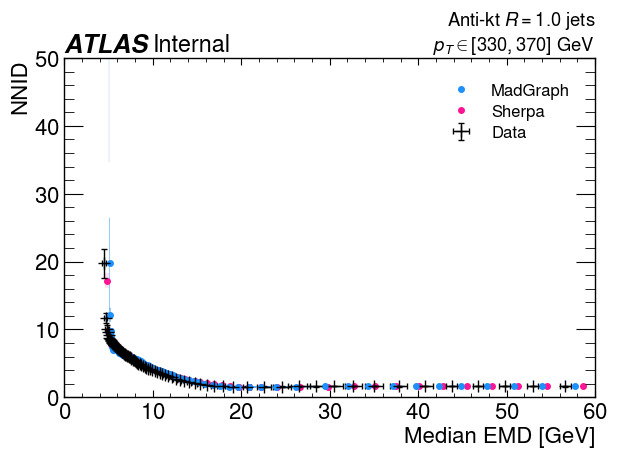

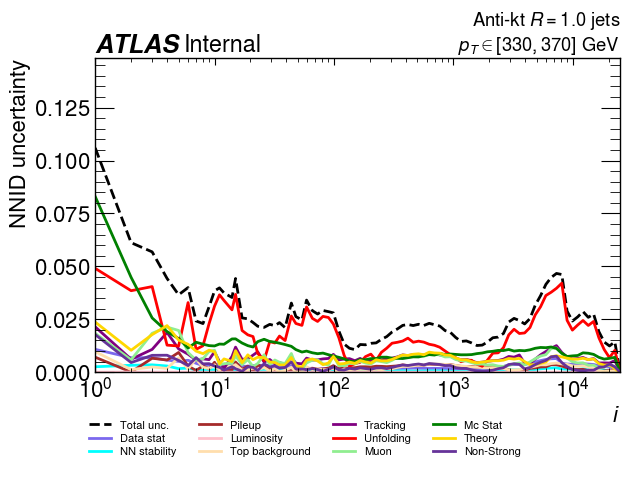

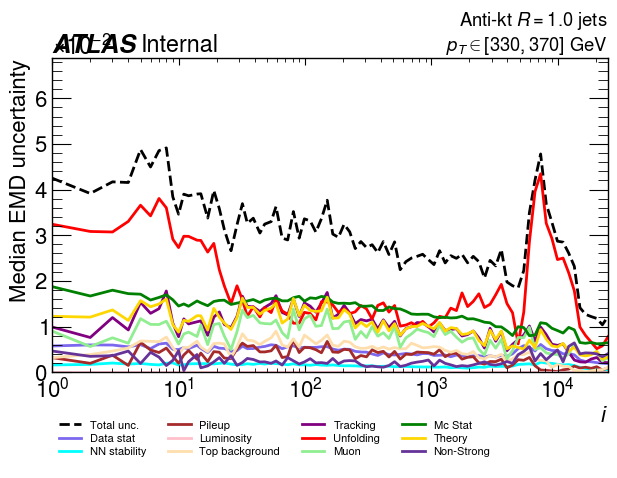

In [12]:
import visualize as vis
data_plot, uc_nnid, uc_avgr = vis.plot_nnid_data(
    mc_results=data_results,
    hv_results=data_hv_results,
    madgraph_results=truth_madgraph_results,
    sherpa_results=truth_sherpa_results,
    low_limit=0,
    high_limit=100,
    thresholds=plot_thresholds,
    plot_uncertainty_budget=True,
    xlim=(0, 60),
    ylim=(0, 50),
    yscale="linear",
    rlab="Anti-kt $R=1.0$ jets\n$p_T \in [330, 370]$ GeV",
)
data_plot.savefig("plot_storage/data_nnid.pdf", dpi=300)
data_plot.show()
uc_nnid.savefig("plot_storage/data_budget_nnid.pdf", dpi=300)
uc_nnid.show()
uc_avgr.savefig("plot_storage/data_budget_median_emd.pdf", dpi=300)
uc_avgr.show()